In [2]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy as sp
import re
from collections import Counter
from copy import deepcopy
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import os
import ast
from scipy import stats 
from scipy.odr import Model, RealData, ODR
from scipy.stats import spearmanr, wilcoxon, ttest_1samp, ranksums, gaussian_kde, fisher_exact, ttest_ind, kruskal, mannwhitneyu, binomtest
from matplotlib import gridspec
from matplotlib_venn import venn3
import zipfile
from glob import glob
import gzip
import tarfile
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FixedLocator
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.patches as mpatches
from itertools import combinations
import pingouin as pg

print("packages have been successfully read in!")

packages have been successfully read in!


In [3]:
## Setting directories and reading in data 
# Reflect output from AAS pipeline (proj_dir), output folder (aa_subs_dir), and sample map for each sample 
# For reproducing analysis of the following datasets, it is highly recommended to maintain the same project directory structure... 

print("loading directories...")
CODE_DIR        = '/Users/alexmaropakis/Projects/BrainDecode/'
PROJ_DIR        = '/Users/alexmaropakis/Projects/Project_BrainDecode/'
SAMPLE_MAPS_DIR = CODE_DIR + 'Dependencies/Sample_maps/'
SUPP_DIR        = PROJ_DIR + 'Supplementary_Tables/'
RAW_DIR         = PROJ_DIR + 'Raw_Quant/'
INDIR           = PROJ_DIR + 'Analysis_Inputs/Takasugi_2024/'
OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/Takasugi_2024/'
DEPDIR          = CODE_DIR + 'Dependencies/Takasugi_2024/'
FRAG_DIR         = PROJ_DIR + 'frag_output/Takasugi_2024/'   # FragPipe: <Tissue>/<tissue>_1/ holds psm.tsv + per-fraction *.tsv
PLOT_DIR        = PROJ_DIR + 'Plots/Takasugi_2024/'

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(SUPP_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)

## Define dataset/TMT set folders 

# Takasugi et al., 2024
#S1 AORTA
aorta_proj_dir      = OUTDIR + 'Aorta/'
aorta_aa_subs_dir   = INDIR + 'Aorta/'
aorta_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_aorta.xlsx')
aorta_samples       = ['S'+str(i) for i in list(set(aorta_sample_map['TMT plex']))]
aorta_frag            = FRAG_DIR + 'Aorta/aorta_1/'

#S2 BRAIN 
brain_proj_dir      = OUTDIR + 'Brain/'
brain_aa_subs_dir   = INDIR + 'Brain/'
brain_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_brain.xlsx')
brain_samples       = ['S'+str(i) for i in list(set(brain_sample_map['TMT plex']))]
brain_frag            = FRAG_DIR + 'Brain/brain_1/'

#S3 HEART
heart_proj_dir      = OUTDIR + 'Heart/'
heart_aa_subs_dir   = INDIR + 'Heart/'
heart_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_heart.xlsx')
heart_samples       = ['S'+str(i) for i in list(set(heart_sample_map['TMT plex']))]
heart_frag            = FRAG_DIR + 'Heart/heart_1/'

#S4 KIDNEY
kidney_proj_dir      = OUTDIR + 'Kidney/'
kidney_aa_subs_dir   = INDIR + 'Kidney/'
kidney_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_kidney.xlsx')
kidney_samples       = ['S'+str(i) for i in list(set(kidney_sample_map['TMT plex']))]
kidney_frag            = FRAG_DIR + 'Kidney/kidney_1/'

#S5 LIVER
liver_proj_dir      = OUTDIR + 'Liver/'
liver_aa_subs_dir   = INDIR + 'Liver/'
liver_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_liver.xlsx')
liver_samples       = ['S'+str(i) for i in list(set(liver_sample_map['TMT plex']))]
liver_frag            = FRAG_DIR + 'Liver/liver_1/'

#S6 LUNG
lung_proj_dir      = OUTDIR + 'Lung/'
lung_aa_subs_dir   = INDIR + 'Lung/'
lung_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_lung.xlsx')
lung_samples       = ['S'+str(i) for i in list(set(lung_sample_map['TMT plex']))]
lung_frag            = FRAG_DIR + 'Lung/lung_1/'

#S7 MUSCLE
muscle_proj_dir      = OUTDIR + 'Muscle/'
muscle_aa_subs_dir   = INDIR + 'Muscle/'
muscle_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_muscle.xlsx')
muscle_samples       = ['S'+str(i) for i in list(set(muscle_sample_map['TMT plex']))]
muscle_frag            = FRAG_DIR + 'Muscle/muscle_1/'

#S8 SKIN
skin_proj_dir      = OUTDIR + 'Skin/'
skin_aa_subs_dir   = INDIR + 'Skin/'
skin_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_skin.xlsx')
skin_samples       = ['S'+str(i) for i in list(set(skin_sample_map['TMT plex']))]
skin_frag            = FRAG_DIR + 'Skin/skin_1/'


#lists to quickly index dataset-specific sample maps from just the dataset name
datasets = ['Aorta', 'Brain', 'Heart', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Skin']
data_dir_list = [aorta_aa_subs_dir, brain_aa_subs_dir, heart_aa_subs_dir, kidney_aa_subs_dir, liver_aa_subs_dir, lung_aa_subs_dir, muscle_aa_subs_dir, skin_aa_subs_dir]
samples_list = [aorta_samples, brain_samples, heart_samples, kidney_samples, liver_samples, lung_samples, muscle_samples, skin_samples]
sample_map_list = [aorta_sample_map, brain_sample_map, heart_sample_map, kidney_sample_map, liver_sample_map, lung_sample_map, muscle_sample_map, skin_sample_map]
proj_dir_list = [aorta_proj_dir, brain_proj_dir, heart_proj_dir, kidney_proj_dir, liver_proj_dir, lung_proj_dir, muscle_proj_dir, skin_proj_dir]
frag_dir_list = [aorta_frag, brain_frag, heart_frag, kidney_frag, liver_frag, lung_frag, muscle_frag, skin_frag]


print("directories loaded successfully!")

loading directories...
directories loaded successfully!


In [4]:
# Read in data generated from dependencies code
# if dependencies have not been generated, go back and generate in Analysis_Dependencies.ipynb

pos_prob_df = pd.read_csv(DEPDIR+'Position_probability_fragment_ion_data.csv', index_col=0)
print(pos_prob_df)
frag_dict = pickle.load(open(DEPDIR+'Fragment_ion_dict.p', 'rb')) ### keys of frag_dict refer to the index in pos_prob_df
print(frag_dict)

SAAP_quant_df = pd.read_excel(DEPDIR+'SAAP_precursor_reporter_quant.xlsx', index_col=0)
#SAAP_precursor_reporter_quant_data.xlsx contains both precursor and reporter ion data for validated SAAPs
# print(SAAP_quant_df)
SAAP_quant_df_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds] for ds in datasets]

                              SAAP                             BP       AAS  \
0                         PATVSLPR                       VATVSLPR    V to P   
1                         PFLENVIR                       VFLENVIR    V to P   
2                      PGDLGVDLTSK                    AGDLGVDLTSK    A to P   
3                        LPGGTTPGK                      LVGGTTPGK    V to P   
4                        LEQEITTYR                      LEQEIATYR    A to T   
..                             ...                            ...       ...   
156   ETTWHGQGQDQGQGPSQESAAEQGAVEK   ETPWHGQGQDQGQGPSQESAAEQGAVEK    P to T   
157  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ    P to T   
158        DNLTLWNSDTQGDEAEAGEGGEN        DNLTLWTSDTQGDEAEAGEGGEN    T to N   
159            DSTYSMSSLLTLTKDEYER            DSTYSMSSTLTLTKDEYER  T to I/L   
160            LYTWGVVEVENPEHNDFLK            LYPWGVVEVENPEHNDFLK    P to T   

     AAS index  Positional probability  charge TMT 

what do i need to do ?

filter to the highest confidence peptides

show all validation metrics 

all correlations 

miscleavages and everything 

very raw data level

standardize a method of referring to the data

# Raw Data Inspection

In [5]:
# for frag_dir in frag_dir_list:
#     psm = pd.read_csv(frag_dir + 'psm.tsv', sep='\t', low_memory=False)
#     # print(psm.ndim)
#     # print(psm.head(10))
#     print(psm)

#     for index, col_name in enumerate(psm.columns):
#         print(f"{index}: {col_name}")

#     # Filter out decoys and contaminants
#     n_before = len(psm)
#     psm = psm[(~psm['Is Decoy']) & (~psm['Is Contaminant'])]
#     n_after = len(psm)
#     n_removed = n_before - n_after 
#     # print(f"Number of PSMs removed after filtering decoys/contaminants: {n_removed}")
#     # print(f"Number of PSMs: {len(psm)}")

#     # Plot distribution of probability (PEP)
#     sns.set_style('darkgrid')
#     fig, ax = plt.subplots(figsize=(4,4)) 
#     PEP = (psm['Probability'].dropna() - 1)
#     a = sns.histplot(PEP, bins=20, color=colors[0], alpha=1, linewidth=0)
#     spectra_string = psm['Spectrum'].iloc[0]
#     plt.title(f"{spectra_string.split('TMT16')[0]}")
#     # plt.savefig(RAW_DIR + f"{spectra_string}_PEP_QC.pdf", bbox_inches='tight')
#     # plt.savefig(RAW_DIR + f"{spectra_string}_PEP_QC.png", dpi=600, bbox_inches='tight')
    
#     # Plot distribution of purity
#     fig,ax = plt.subplots(figsize=(4,4))
#     b = sns.histplot(psm['Purity'].dropna(), bins=20, color=colors[1], alpha=1, linewidth=0)
#     spectra_string = psm['Spectrum'].iloc[0]
#     plt.title(f"{spectra_string.split('TMT16')[0]}")
#     # plt.savefig(RAW_DIR + f"{spectra_string}_PosProb_QC.pdf", bbox_inches='tight')
#     # plt.savefig(RAW_DIR + f"{spectra_string}_PosProb_QC.png", dpi=600, bbox_inches='tight')

#     # Distribution of miscleavages
#     fig,ax = plt.subplots(figsize=(4,4))
#     c = sns.histplot(psm['Number of Missed Cleavages'], bins=5, color=colors[2], alpha=1, linewidth=0)
#     spectra_string = psm['Spectrum'].iloc[0]
#     plt.title(f"{spectra_string.split('TMT16')[0]}")
#     # plt.savefig(RAW_DIR + f"{spectra_string}_Miscleavage_QC.pdf", bbox_inches='tight')
#     # plt.savefig(RAW_DIR + f"{spectra_string}_Miscleavage_QC.png", dpi=600, bbox_inches='tight')

#     # Distribution of charge state 
#     fig,ax = plt.subplots(figsize=(4,4))
#     d = sns.histplot(psm['Charge'], bins=5, color=colors[3], alpha=1, linewidth=0)
#     spectra_string = psm['Spectrum'].iloc[0]
#     plt.title(f"{spectra_string.split('TMT16')[0]}")
#     # plt.savefig(RAW_DIR + f"{spectra_string}_Charge_QC.pdf", bbox_inches='tight')
#     # plt.savefig(RAW_DIR + f"{spectra_string}_Charge_QC.png", dpi=600, bbox_inches='tight')

#     # Distribution of retention time agreement scores
#     fig,ax = plt.subplots(figsize=(4,4))
#     d = sns.histplot(psm['RTScore'], bins=30, color=colors[4], alpha=1, linewidth=0)
#     spectra_string = psm['Spectrum'].iloc[0]
#     plt.title(f"{spectra_string.split('TMT16')[0]}")
#     # plt.savefig(RAW_DIR + f"{spectra_string}_RT_QC.pdf", bbox_inches='tight')
#     # plt.savefig(RAW_DIR + f"{spectra_string}_RT_QC.png", dpi=600, bbox_inches='tight')

#     # Distribution of spectra prediction scores 
#     fig,ax = plt.subplots(figsize=(4,4))
#     d = sns.histplot(psm['Hyperscore'], bins=30, color=colors[5], alpha=1, linewidth=0)
#     spectra_string = psm['Spectrum'].iloc[0]
#     plt.title(f"{spectra_string.split('TMT16')[0]}")
#     # plt.savefig(RAW_DIR + f"{spectra_string}_Hyperscore_QC.pdf", bbox_inches='tight')
#     # plt.savefig(RAW_DIR + f"{spectra_string}_Hyperscore_QC.png", dpi=600, bbox_inches='tight')

#     # Missing values 
#     cols = psm.columns
#     total_val = len(psm) * len(cols)
#     nonmissing_val = sum(psm[c].notna().sum() for c in cols)
#     completeness = 100*(nonmissing_val/total_val)
#     print(f"Data completeness: {completeness}")

In [6]:
# for frag_dir in frag_dir_list:
#     for p in glob(frag_dir + "*_edited.pin"):
#         pin = pd.read_csv(p, sep='\t', low_memory=False)

#     # for index, col_name in enumerate(pin.columns):
#     #     print(f"{index}: {col_name}")

#     # print(pin)
    
#     sns.set_style('darkgrid')
#     fig,ax = plt.subplots(figsize=(4,4))
#     a = sns.histplot(pin['hypergeometric_probability'], bins=50, color=colors[1], alpha=1, linewidth=0)
#     spectra_string = pin['SpecId'].iloc[0]
#     plt.title(f"{spectra_string.split('TMT16')[0]}")
#     # plt.savefig(RAW_DIR + f"{spectra_string}_Hypergeo_QC.pdf", bbox_inches='tight')
#     # plt.savefig(RAW_DIR + f"{spectra_string}_Hypergeo_QC.png", dpi=600, bbox_inches='tight')

#     fig,ax = plt.subplots(figsize=(4,4))
#     b = sns.histplot(pin['weighted_spectral_entropy'], bins=50, color=colors[2], alpha=1, linewidth=0)
#     spectra_string = pin['SpecId'].iloc[0]
#     plt.title(f"{spectra_string.split('TMT16')[0]}")
#     # plt.savefig(RAW_DIR + f"{spectra_string}_spectralEntropy_QC.pdf", bbox_inches='tight')
#     # plt.savefig(RAW_DIR + f"{spectra_string}_spectralEntropy_QC.png", dpi=600, bbox_inches='tight')

#     fig,ax = plt.subplots(figsize=(4,4))
#     c = sns.histplot(pin['delta_RT_loess'], bins=50, color=colors[3], alpha=1, linewidth=0)
#     spectra_string = pin['SpecId'].iloc[0]
#     plt.title(f"{spectra_string.split('TMT16')[0]}")
#     # plt.savefig(RAW_DIR + f"{spectra_string}_deltaRT_QC.pdf", bbox_inches='tight')
#     # plt.savefig(RAW_DIR + f"{spectra_string}_deltaRT_QC.png", dpi=600, bbox_inches='tight')

# Filtering Steps

## Remove immunoglobulins and trypsin-mapping SAAPs 

In [7]:
## Assign each SAAP a gene and accession & drop Igs/trypsins 

# Build dictionaries of peptide ID, gene, and accessions 
acc_gene = {}
acc_desc = {}
for frag_dir in frag_dir_list:
    cols = ['Protein ID', 'Gene', 'Protein Description', 'Mapped Proteins', 'Mapped Genes']
    psm=pd.read_csv(frag_dir +'psm.tsv', sep='\t', low_memory=False, usecols=lambda c: c in cols)

    for acc, gene, desc in zip(psm['Protein ID'], psm.get('Gene', ''), psm.get('Protein Description', '')):
        a = str(acc)
        if pd.notna(desc) and str(desc).strip():
            acc_desc.setdefault(a, str(desc).strip())
        if pd.notna(gene) and str(gene).strip():
            acc_gene.setdefault(a, str(gene).strip())
print(f'{len(acc_desc):,} reference proteins parsed from psm.tsv')

seq_to_proteins = {}
for dataset, frag_dir in zip(datasets, frag_dir_list):
    cols = ['Peptide', 'Protein', 'Mapped Proteins']
    psm=pd.read_csv(frag_dir +'psm.tsv', sep='\t', low_memory=False, usecols=lambda c: c in cols)
    for seq, prot, mapped in zip(psm['Peptide'], psm['Protein'].astype(str),
                                 psm.get('Mapped Proteins', pd.Series('')).astype(str)):
        if prot and prot != 'nan':
            full = prot if mapped in ('', 'nan') else prot + ';' + mapped.replace(', ', ';')
            seq_to_proteins.setdefault((dataset, seq), full)
print(f'{len(seq_to_proteins):,} unique (tissue, peptide) pairs indexed across {len(frag_dir_list)} psm.tsv files')

def prot_to_acc(protein_str):
    lead_only = True
    accs = []
    for tok in str(protein_str).split(';'):
        if tok.startswith('MTP'):
            continue
        m = re.match(r'(?:sp|tr)\|([^|]+)\|', tok) or re.match(r'^([A-Z0-9][A-Z0-9-]+)$', tok)
        if m:
            accs.append((m.group(1)))  
    accs = list(dict.fromkeys(accs))  
    return accs[:1] if lead_only else accs

row_accs = [prot_to_acc(seq_to_proteins.get((ds, bp), ''))
            for ds, bp in zip(SAAP_quant_df['Dataset'], SAAP_quant_df['BP_seq'])]
row_genes = [[acc_gene.get(a, '') for a in accs] for accs in row_accs]
row_descs = [[acc_desc.get(a, '') for a in accs] for accs in row_accs]

def first_nonempty(values):
    return next((v for v in values if v), '')

# append observations to SAAP_quant_df
SAAP_quant_df['Source_accessions'] = [';'.join(accs) for accs in row_accs]
SAAP_quant_df['Source_gene']       = [first_nonempty(g) for g in row_genes]
SAAP_quant_df['Source_protein']    = [first_nonempty(d) for d in row_descs]
print(SAAP_quant_df[['MTP_seq', 'BP_seq', 'Dataset', 'Source_gene', 'Source_protein']].to_string())

12,516 reference proteins parsed from psm.tsv
450,075 unique (tissue, peptide) pairs indexed across 8 psm.tsv files
                                        MTP_seq                               BP_seq Dataset    Source_gene                                                                                                    Source_protein
Row Number                                                                                                                                                                                                                   
0                                      PATVSLPR                             VATVSLPR   Aorta                                                                                                                                 
1                                      PATVSLPR                             VATVSLPR   Aorta                                                                                                                              

In [8]:
# flag immunoglobulin (antibody chains) and trypsin (digestion contaminant) source proteins.
# Matching is gene- and accession-based to avoid false positives such as Ig-superfamily
# members, IgLON, anti-trypsin, or chymotrypsin.
ig_gene_re   = re.compile(r'(?i)^Ig[hkl][vjdcmage0-9]')
ig_desc_re   = re.compile(r'(?i)^(immunoglobulin|ig)[ -](heavy|kappa|lambda|gamma|mu|alpha|delta|epsilon|j)')
tryp_desc_re = re.compile(r'(?i)\btrypsin')
tryp_skip_re = re.compile(r'(?i)(anti-?trypsin|trypsin inhibitor|chymotrypsin)')
TRYPSIN_ACCESSIONS = {'P00761', 'P00760'}  # Sus scrofa / Bos taurus digestion trypsin contaminants

def is_immunoglobulin(accs):
    return any(ig_gene_re.match(acc_gene.get(a, '')) or acc_gene.get(a, '').lower() == 'jchain'
               or ig_desc_re.match(acc_desc.get(a, '')) for a in accs)

def is_trypsin(accs):
    return any(a in TRYPSIN_ACCESSIONS or
               (tryp_desc_re.search(acc_desc.get(a, '')) and not tryp_skip_re.search(acc_desc.get(a, '')))
               for a in accs)

SAAP_quant_df['immunoglobulin'] = ['YES' if is_immunoglobulin(accs) else 'NO' for accs in row_accs]
SAAP_quant_df['trypsin']        = ['YES' if is_trypsin(accs) else 'NO' for accs in row_accs]
print(f"\n{(SAAP_quant_df['immunoglobulin'] == 'YES').sum():,} SAAP observations match immunoglobulins")
print(f"{(SAAP_quant_df['trypsin'] == 'YES').sum():,} SAAP observations match trypsin")
print('immunoglobulin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].unique()))
print('trypsin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_accessions'].unique()))


208 SAAP observations match immunoglobulins
0 SAAP observations match trypsin
immunoglobulin source proteins removed: ['Ig heavy chain V region AC38 205.12', 'Ig heavy chain V region MOPC 104E', 'Immunoglobulin heavy variable V1-18 (Fragment)', 'Immunoglobulin heavy variable V1-42', 'Immunoglobulin kappa chain variable 6-25 (Fragment)', 'Immunoglobulin kappa constant', 'Immunoglobulin kappa variable 4-53', 'Immunoglobulin kappa variable 4-57 (Fragment)']
trypsin source proteins removed: []


8
0
468
          Category  Count
0  Immunoglobulins      8
1         Trypsins      0
2            SAAPs    468


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_52399/1809934607.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Set2',alpha=1)


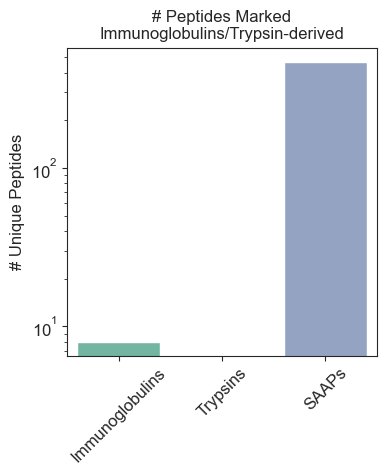

In [9]:
# Plot the number of trypsin/immunoglobulin-matching peptides 
n_immunoglobulin = SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].nunique()
print(n_immunoglobulin)

n_trypsin = SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_protein'].nunique()
print(n_trypsin)

n_main_SAAP = SAAP_quant_df.loc[(SAAP_quant_df['trypsin'] == 'NO') & (SAAP_quant_df['immunoglobulin'] == 'NO'), 'Source_protein'].nunique()
print(n_main_SAAP)

plot_df = pd.DataFrame({'Category': ['Immunoglobulins', 'Trypsins', 'SAAPs'],'Count': [n_immunoglobulin, n_trypsin, n_main_SAAP]})
print(plot_df)

plt.figure(figsize=(4,4))
sns.set_style(style='ticks')
ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Set2',alpha=1)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('# Unique Peptides',fontsize=12)
ax.set_title('# Peptides Marked\nImmunoglobulins/Trypsin-derived',fontsize=12)
ax.tick_params(axis='x',rotation=45,labelsize=12)
ax.tick_params(axis='y',labelsize=12)

plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [10]:
drop_mask = (SAAP_quant_df['immunoglobulin'] == 'YES') | (SAAP_quant_df['trypsin'] == 'YES')
SAAP_quant_df = SAAP_quant_df.loc[~drop_mask].reset_index(drop=True)

## Rescue SAAPs with RT and spectral prediction support from positional probability filtering
A SAAP's positional probability is only high when the MS2 spectrum has the b/y ions
flanking the substituted residue. Low-abundance or poorly-fragmenting peptides often
lack those ions, so a real SAAP can score low purely from missing fragments. A hard
positional-probability cut therefore discards genuine SAAPs.

To recover them we use two orthogonal MSBooster scores from the *_edited.pin files:

  weighted_spectral_entropy : how well the observed spectrum matches the predicted
                              spectrum for the assigned SAAP (higher = better).
  delta_RT_loess            : difference between observed and predicted retention
                              time, loess-calibrated and already absolute
                              (lower = better). Orthogonal to spectral matching.

Both thresholds are calibrated against DECOYS. Each pin row has Label = 1 (target) or
-1 (decoy). We set each threshold to admit a chosen small fraction of decoys
(DECOY_ADMIT), giving every cutoff a known decoy-admission rate rather than an
arbitrary number.

Rule: keep a SAAP if it is confidently localized (positional probability >= cut),
OR if it is uncertainly localized but passes BOTH the entropy and RT thresholds.

Note: the entropy score is one-sided (it only checks the SAAP matches itself), so it
cannot reject an isobaric substitution like I<->L where the SAAP and base peptide give
the same spectrum. Those land at RAAS ~ 0; the check at the end reports how many
rescued SAAPs fall there.

Requires:
  - SAAP_quant_df with 'Positional_probability' and per-SAAP
    'spectral_entropy' and 'delta_RT' columns
  - the *_edited.pin files, used here only to calibrate thresholds from decoys.

In [11]:
## Localization rescue of SAAPs using MSBooster spectral entropy and RT agreement
pos_prob_cut = 0.9
decoy_admit = 0.05  # 5%

# Calibrate thresholds per tissue (no pooling across datasets)
thresholds = {}  # ds -> (entropy_thresh, rt_thresh)
for ds, frag_dir in zip(datasets, frag_dir_list):
    ent_decoy, rt_decoy = [], []
    for f in glob(frag_dir + '*_edited.pin'):
        cols = ['Label', 'weighted_spectral_entropy', 'delta_RT_loess']
        d = pd.read_csv(f, sep='\t', usecols=cols, low_memory=False)
        dec = d[d['Label'] == -1]
        ent_decoy.append(dec['weighted_spectral_entropy'].values)
        rt_decoy.append(dec['delta_RT_loess'].values)
    if not ent_decoy:
        continue
    ent_decoy = np.concatenate(ent_decoy)
    rt_decoy  = np.concatenate(rt_decoy)
    entropy_thresh = np.nanpercentile(ent_decoy, 100 * (1 - decoy_admit))
    rt_thresh      = np.nanpercentile(rt_decoy, 100 * decoy_admit)
    thresholds[ds] = (entropy_thresh, rt_thresh)
    print(f"  {ds}: entropy >= {entropy_thresh:.4f}, delta_RT <= {rt_thresh:.4f}")

# Apply rescue gating per row using that row's own dataset threshold
ent_thresh_col = SAAP_quant_df['Dataset'].map(lambda ds: thresholds[ds][0])
rt_thresh_col  = SAAP_quant_df['Dataset'].map(lambda ds: thresholds[ds][1])

pp  = SAAP_quant_df['Positional_probability']
ent = SAAP_quant_df['spectral_entropy']
rt  = SAAP_quant_df['delta_RT']

pass_localization = pp >= pos_prob_cut
rescued = (pp < pos_prob_cut) & (ent >= ent_thresh_col) & (rt <= rt_thresh_col)

SAAP_quant_df['localization_pass'] = pass_localization
SAAP_quant_df['entropy_rescued']   = rescued
SAAP_quant_df['keep_localization'] = pass_localization | rescued

# Summary
n_total = len(SAAP_quant_df)
n_kept = int(SAAP_quant_df['keep_localization'].sum())
print(f'passed positional prob >= {pos_prob_cut}: {int(pass_localization.sum()):,}')
print(f'rescued (entropy AND RT):         {int(rescued.sum()):,}')
print(f'total kept:                       {n_kept:,} of {n_total:,} ({n_kept/n_total:.1%})')
print(f'dropped:                          {n_total - n_kept:,}')

  Aorta: entropy >= 0.9439, delta_RT <= 2.2677
  Brain: entropy >= 0.9292, delta_RT <= 2.3314
  Heart: entropy >= 0.9366, delta_RT <= 2.4430
  Kidney: entropy >= 0.9487, delta_RT <= 2.2603
  Liver: entropy >= 0.9365, delta_RT <= 2.2882
  Lung: entropy >= 0.9336, delta_RT <= 2.4064
  Muscle: entropy >= 0.9493, delta_RT <= 2.4355
  Skin: entropy >= 0.9398, delta_RT <= 2.4422
passed positional prob >= 0.9: 9,040
rescued (entropy AND RT):         4,672
total kept:                       13,712 of 25,216 (54.4%)
dropped:                          11,504


In [12]:
# Do rescued SAAPs pile up at RAAS ~ 0? [isobaric artifacts]
# This determines what percentage of SAAPs sit at abundance comparable to base peptide 
for col in ['Reporter_RAAS', 'Prec_RAAS']:
    if col in SAAP_quant_df.columns:
        r = pd.to_numeric(SAAP_quant_df.loc[rescued, col], errors='coerce').dropna()
        if len(r):
            print(f"Rescued {col} within |RAAS|<0.15: {(r.abs() < 0.15).mean():.1%}")

Rescued Reporter_RAAS within |RAAS|<0.15: 7.5%
Rescued Prec_RAAS within |RAAS|<0.15: 7.1%


entropy >= 0.940: keeps 49.7% targets, 5.0% decoys
delta_RT <= 2.36:  keeps 31.2% targets, 5.0% decoys


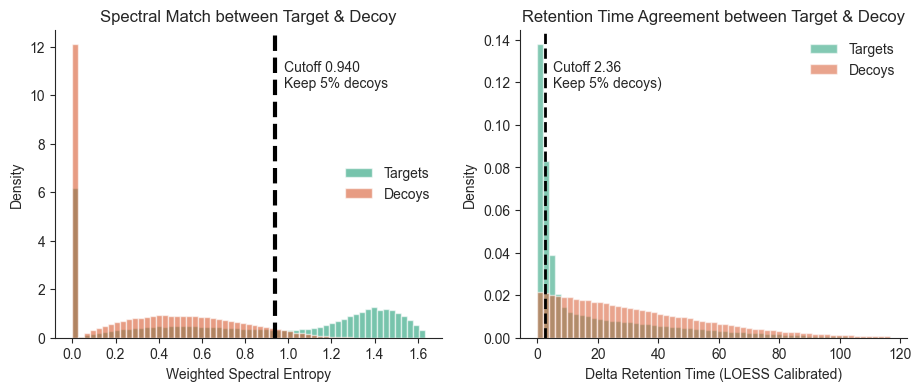

In [13]:
# Visualize the decoy-calibrated rescue thresholds 

ent_t = [] # t = target 
ent_d = [] # d = decoy
rt_t = [] 
rt_d = [] 
for frag_dir in frag_dir_list:
    for f in glob(frag_dir + '*_edited.pin'):
        d = pd.read_csv(f, sep='\t', usecols=['Label', 'weighted_spectral_entropy', 'delta_RT_loess'], low_memory=False)
        t = d[d['Label'] == 1]
        dec = d[d['Label'] == -1]

        ent_t.append(t['weighted_spectral_entropy'].values)
        ent_d.append(dec['weighted_spectral_entropy'].values)
        rt_t.append(t['delta_RT_loess'].values)
        rt_d.append(dec['delta_RT_loess'].values)
ent_t = np.concatenate(ent_t)
ent_d = np.concatenate(ent_d)
rt_t = np.concatenate(rt_t)
rt_d = np.concatenate(rt_d)

ent_thresh = np.nanpercentile(ent_d, 100 * (1 - decoy_admit))
rt_thresh = np.nanpercentile(rt_d, 100 * decoy_admit)

# plotting 
target_color, decoy_color = '#1D9E75', '#D85A30'
fig, axes = plt.subplots(1,2, figsize=(11,4))

# entropy panel 
ax = axes[0]
bins = np.linspace(0, np.nanpercentile(ent_t, 99.5), 60)
ax.hist(ent_t, bins=bins, density=True, color=target_color, alpha=0.6, label='Targets')
ax.hist(ent_d, bins=bins, density=True, color = decoy_color, alpha=0.6, label='Decoys')
ax.axvline(ent_thresh, color='k', ls='--', lw=3)
ax.annotate(f"Cutoff {ent_thresh:.3f}\nKeep {decoy_admit:.0%} decoys", xy=(ent_thresh, ax.get_ylim()[1]*0.9),
                xytext=(6,0), textcoords="offset points", va="top", fontsize=10)
ax.set_xlabel("Weighted Spectral Entropy")
ax.set_ylabel("Density")
ax.set_title("Spectral Match between Target & Decoy")
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# retention time panel 
ax = axes[1]
bins = np.linspace(0, np.nanpercentile(rt_d, 99), 60)
ax.hist(rt_t, bins=bins, density=True, color=target_color, alpha=0.55, label='Targets')
ax.hist(rt_d, bins=bins, density=True, color=decoy_color, alpha=0.55, label='Decoys')
ax.axvline(rt_thresh, color='k', ls='--', lw=2)
ax.annotate(f'Cutoff {rt_thresh:.2f}\nKeep {decoy_admit:.0%} decoys)',
            xy=(rt_thresh, ax.get_ylim()[1]*0.9), xytext=(6, 0),
            textcoords='offset points', va='top', fontsize=10)
ax.set_xlabel("Delta Retention Time (LOESS Calibrated)")
ax.set_ylabel("Density")
ax.set_title("Retention Time Agreement between Target & Decoy")
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig(PLOT_DIR + "rescue_threshold_target_decoy.pdf", bbox_inches='tight')
plt.savefig(PLOT_DIR + "rescue_threshold_target_decoy.png", dpi=600, bbox_inches='tight')


# report keep-rates at these thresholds
print(f'entropy >= {ent_thresh:.3f}: keeps {(ent_t>=ent_thresh).mean():.1%} targets, {(ent_d>=ent_thresh).mean():.1%} decoys')
print(f'delta_RT <= {rt_thresh:.2f}:  keeps {(rt_t<=rt_thresh).mean():.1%} targets, {(rt_d<=rt_thresh).mean():.1%} decoys')

In [14]:
# Apply filtering
SAAP_quant_df = SAAP_quant_df[SAAP_quant_df['keep_localization']].copy()
print(SAAP_quant_df)

      Dataset                        MTP_seq                         BP_seq  \
0       Aorta                       PATVSLPR                       VATVSLPR   
1       Aorta                       PATVSLPR                       VATVSLPR   
2       Aorta                       PATVSLPR                       VATVSLPR   
3       Aorta                       PATVSLPR                       VATVSLPR   
4       Aorta                       PATVSLPR                       VATVSLPR   
...       ...                            ...                            ...   
25179    Skin  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ   
25180    Skin  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ   
25181    Skin  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ   
25182    Skin  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ   
25183    Skin  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ   

       aa_sub tmt_set  Positional_probability  spec

# Visualize Validation Metrics

### Positional probability filtering

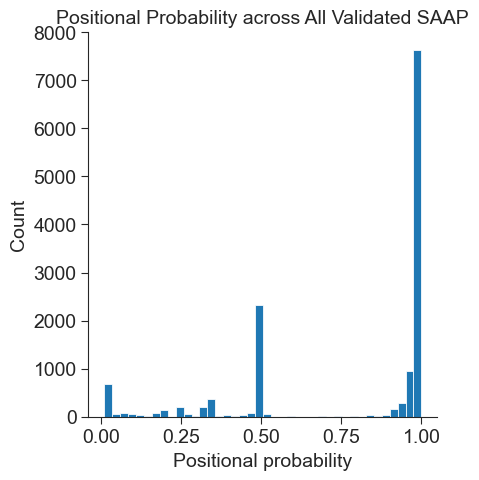

In [15]:
# Filtered distribution 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
loc_df=SAAP_quant_df['Positional_probability']
loc_df=(loc_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=loc_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('Positional probability',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('Positional Probability across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.png',dpi=600,bbox_inches='tight')

### PEP filtering

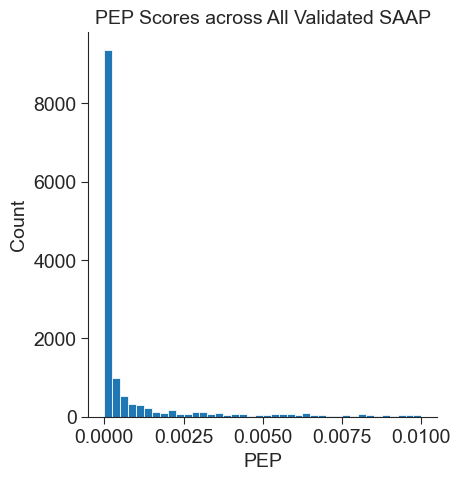

In [16]:
# Plot PEP distribution for all SAAP 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
pep_df=SAAP_quant_df['SAAP_PEP']
pep_df=(pep_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=pep_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('PEP',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('PEP Scores across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'PEP_all_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'PEP_all_AAS.png',dpi=600,bbox_inches='tight')